# KANVAS, Phase 6: Lookback-Window Ablation and Case-Level Audit Trails

Two things were still missing before KANVAS is a complete research contribution:

1. **A sensitivity check on `lookback_hours`.** The 1-hour telemetry window was picked in Phase 2, when the worker-keyed join removed nearly every failure and had to be replaced by a machine-keyed lookback. It was flagged as a future ablation then and never run. **Part A** tests whether 1 hour was load-bearing or arbitrary.
2. **A case-level explainability audit.** `KAAM.explain()` has been in `model.py` since Day 1 and had never been run on a real task. **Part B** runs it on four test cases picked by a fixed rule, draws each one as an audit trail, and checks it against the model's own forward pass.

### Nothing is re-tuned

Every choice below was fixed in Phases 3-5 and is applied unchanged, at every window width:

| Choice | Value | Fixed in |
|---|---|---|
| Smoothness penalty $\lambda$ | 0.001 | Phase 3 |
| Early-stopping patience / max epochs | 15 / 500 | Phase 3 |
| KAAM learning rate, knots, spline order | 0.01, 10, 3 | Phase 3 |
| Input scaling | min-max, fitted on each training split only | Phase 2 |
| Split proportions | 70 / 15 / 15, stratified | Phase 3 |
| Canonical split / initialization seed | `random_state=42` / seed 0 | Phase 5 |
| Decision threshold | 0.5, the threshold Phase 5 treated as final (`THRESHOLD = 0.5` in `kanvas/stability.py`, "not re-tuned per run"); Phase 3's validation-tuned 0.60 was never carried forward | Phases 4-5 |
| Dataset sample | 40,000 tasks, `random_state=42` | Phase 5 |

`data.py`, `bspline.py`, `model.py`, `training.py`, `baselines.py` and `shap_analysis.py` are imported unmodified. This phase adds orchestration code only: `kanvas/ablation.py` and `kanvas/case_studies.py`.

### Two design decisions, fixed before any width was trained

- **Each task keeps one role at every width.** A wider window keeps more tasks, so the five datasets are five different row sets. Re-running the split on each one would draw five unrelated test sets, and Phase 5 measured that the split alone moves test AUC with a standard deviation of 0.0104. Instead, the canonical tasks keep Phase 5's split exactly, and tasks that exist only at other widths get their own stratified 70/15/15 split. The paired bootstrap then compares each width with 1 hour on every test task the two share.
- **Waterfall bars are measured from the average training task.** `explain()`'s raw $\varphi_i(x_i)$ values carry per-feature offsets the data cannot identify: only the bias plus the sum of the offsets is pinned down. Four of the ten raw $\varphi_i$ sit below zero for *every* training task, so a raw bar's sign says nothing about the task. Each bar is therefore $\varphi_i(x_i)$ minus $\varphi_i$'s training mean, and the waterfall starts at the average training task's log-odds. The bars still sum exactly to the model's logit, and for an additive model they are exactly the SHAP values of Phase 4's `kaam_shap_values`. The raw `explain()` values are printed under every chart, and the consistency check runs on them.

In [1]:
import json
import os
import sys
import time
sys.path.append("..")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from cycler import cycler
from sklearn.metrics import brier_score_loss

import kanvas.ablation as ab
import kanvas.case_studies as cs
import kanvas.stability as st
from kanvas.data import FEATURE_NAMES
from kanvas.shap_analysis import kaam_shap_values
from kanvas.training import classification_metrics, predict_proba

%matplotlib inline
pd.set_option("display.width", 240)

# Chart style, unchanged from Phases 2-5 so every figure in the paper matches.
SURFACE, INK, INK_2, MUTED, BASELINE = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#c3c2b7"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlecolor": INK, "axes.labelcolor": INK_2, "text.color": INK,
    "xtick.color": BASELINE, "ytick.color": BASELINE, "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8, "grid.linestyle": "-",
    "axes.prop_cycle": cycler(color=["#2a78d6", "#eb6834"]), "lines.linewidth": 2.0,
    "legend.frameon": False, "font.size": 10,
})

RAW_DIR = "../data/raw"
LARGE_CSV = "../data/processed/kanvas_features_large.csv"
LOOKBACK_DIR = "../data/processed/lookback"
PHASE5_BENCHMARK = "../data/processed/publication/kanvas_benchmark_results.csv"
CHECKPOINT = "../models/kaam_canonical.pt"
FIG_DIR = "../figures/phase6"
os.makedirs(FIG_DIR, exist_ok=True)

print(f"canonical rule: split random_state={st.CANONICAL_SPLIT_STATE}, init seed {st.CANONICAL_INIT_SEED}, "
      f"threshold {st.THRESHOLD}")
print(f"frozen: lambda={st.LAMBDA_SMOOTH}, patience={st.PATIENCE}, max_epochs={st.MAX_EPOCHS}, lr={st.KAAM_LR}, "
      f"knots={st.NUM_KNOTS}, order={st.SPLINE_ORDER}")
print(f"lookback widths {ab.LOOKBACK_HOURS} h, canonical {ab.CANONICAL_LOOKBACK:g} h; "
      f"sample {ab.SAMPLE_N_TASKS:,} tasks at random_state={ab.SAMPLE_STATE}")

canonical rule: split random_state=42, init seed 0, threshold 0.5
frozen: lambda=0.001, patience=15, max_epochs=500, lr=0.01, knots=10, order=3
lookback widths [0.5, 1.0, 2.0, 4.0, 6.0] h, canonical 1 h; sample 40,000 tasks at random_state=42


## 0. Reproduce the Phase 5 canonical model

Everything below runs on Phase 5's canonical setup, so the first job is to get that exact model back. If Phase 5 saved a checkpoint and its split indices, they are loaded as they are. If it did not, both are rebuilt by the rule Phase 5 documented, and the rebuilt model has to reproduce Phase 5's reported test numbers **exactly**. If it doesn't, this notebook stops here rather than carrying on with a different number.

In [2]:
# Did Phase 5 save a model checkpoint or split indices? Search the whole project, then Phase 5's own code.
SUFFIXES = (".pt", ".pth", ".ckpt", ".safetensors", ".pkl", ".pickle", ".joblib", ".npy", ".npz")
found = []
for folder, subdirs, files in os.walk(".."):
    subdirs[:] = [d for d in subdirs if d not in {".venv", ".git", "__pycache__", ".ipynb_checkpoints"}]
    found += [os.path.normpath(os.path.join(folder, f)) for f in files if f.endswith(SUFFIXES)]
not_ours = [path for path in found if path != os.path.normpath(CHECKPOINT)]  # this notebook writes CHECKPOINT itself
print(f"model / split files in the project: {found or 'none'}")
print(f"  of which not written by this notebook: {not_ours or 'none'}")

with open("05_scale_and_stability.ipynb", encoding="utf-8") as fh:
    phase5_code = "\n".join("".join(cell["source"]) for cell in json.load(fh)["cells"] if cell["cell_type"] == "code")
with open("../kanvas/stability.py", encoding="utf-8") as fh:
    phase5_code += fh.read()
savers = [call for call in ("torch.save", "pickle.dump", "joblib.dump", "np.save", "to_pickle") if call in phase5_code]
print(f"save calls in notebook 05 or kanvas/stability.py: {savers or 'none'}")

model / split files in the project: ['..\\models\\kaam_canonical.pt']
  of which not written by this notebook: none
save calls in notebook 05 or kanvas/stability.py: none


**Phase 5 saved neither a checkpoint nor split indices**, so both are rebuilt by the rule notebook 05 documented. That rule was fixed in `kanvas/stability.py` before any Phase 5 metric existed: split `random_state=42` (the split seed Phases 3 and 4 used) and initialization seed 0 (the first entry of Experiment A's seed list). The rebuilt model is compared with the full-precision numbers Phase 5 exported to `kanvas_benchmark_results.csv`, not with rounded printouts.

In [3]:
large = pd.read_csv(LARGE_CSV, index_col=["job_name", "task_name"])
X_large, y_large = large[FEATURE_NAMES], large["label"]

t0 = time.perf_counter()
kaam, kaam_result, canonical_splits = cs.reproduce_canonical_model(X_large, y_large)
X_tr, X_va, X_te, y_tr, y_va, y_te = canonical_splits
ranges = kaam_result.feature_ranges
print(f"rebuilt in {time.perf_counter() - t0:.0f}s: {len(X_tr):,} train / {len(X_va):,} val / {len(X_te):,} test "
      f"({int(y_te.sum()):,} test failures); restored epoch {kaam_result.best_epoch}, "
      f"val BCE {kaam_result.best_val_loss:.4f}")
print("notebook 05 printed:  13,222 train / 2,834 val / 2,834 test (779 test failures); "
      "restored epoch 500, val BCE 0.4736\n")

p_te = pd.Series(predict_proba(kaam, X_te, ranges), index=X_te.index)
m = classification_metrics(y_te.to_numpy(), p_te.to_numpy(), st.THRESHOLD)
phase5 = pd.read_csv(PHASE5_BENCHMARK).set_index("model").loc["KAAM"]
check = pd.DataFrame({
    "Phase 5 (exported)": [float(phase5[c]) for c in ("AUC", "accuracy", "F1", "precision", "recall", "Brier")],
    "reproduced": [m["auc"], m["accuracy"], m["f1"], m["precision"], m["recall"], brier_score_loss(y_te, p_te)],
}, index=["test AUC", "test accuracy", "test F1", "test precision", "test recall", "test Brier"])
check["|difference|"] = (check["reproduced"] - check["Phase 5 (exported)"]).abs()
print(check.to_string(formatters={"Phase 5 (exported)": "{:.10f}".format, "reproduced": "{:.10f}".format,
                                  "|difference|": "{:.1e}".format}))

# If the rebuilt model does not reproduce Phase 5, stop and flag it instead of continuing on a different number.
if check["|difference|"].max() > 1e-9:
    raise RuntimeError("the rebuilt model does NOT reproduce Phase 5's canonical numbers; stopping here")
print(f"\nMATCH: test AUC {m['auc']:.6f}, the same as Phase 5's canonical run on every metric "
      f"(largest difference {check['|difference|'].max():.0e}).")

rebuilt in 35s: 13,222 train / 2,834 val / 2,834 test (779 test failures); restored epoch 500, val BCE 0.4736
notebook 05 printed:  13,222 train / 2,834 val / 2,834 test (779 test failures); restored epoch 500, val BCE 0.4736

               Phase 5 (exported)   reproduced |difference|
test AUC             0.7519987881 0.7519987881      0.0e+00
test accuracy        0.8094565984 0.8094565984      0.0e+00
test F1              0.5754716981 0.5754716981      0.0e+00
test precision       0.7423935091 0.7423935091      0.0e+00
test recall          0.4698331194 0.4698331194      5.6e-17
test Brier           0.1527382433 0.1527382433      2.8e-17

MATCH: test AUC 0.751999, the same as Phase 5's canonical run on every metric (largest difference 6e-17).


In [4]:
# Save what Phase 5 did not, so later work (tests, the Kaggle notebook) loads this model instead of retraining.
os.makedirs(os.path.dirname(CHECKPOINT), exist_ok=True)
cs.save_checkpoint(CHECKPOINT, kaam, ranges, canonical_splits, X_large, LARGE_CSV,
                   metrics={"test_auc": m["auc"], "test_accuracy": m["accuracy"], "test_f1": m["f1"],
                            "val_bce": kaam_result.best_val_loss, "best_epoch": kaam_result.best_epoch})
loaded, loaded_ranges, loaded_splits, saved = cs.load_checkpoint(CHECKPOINT, LARGE_CSV)
same_split = all(a.index.equals(b.index) for a, b in zip(loaded_splits, canonical_splits))
same_p = np.array_equal(predict_proba(loaded, loaded_splits[2], loaded_ranges), p_te.to_numpy())
print(f"saved {os.path.normpath(CHECKPOINT)} ({os.path.getsize(CHECKPOINT) / 1024:.0f} KB): weights, the "
      f"train-fitted scaling ranges, and the split as row positions in kanvas_features_large.csv "
      f"(sha256 {saved['source_csv_sha256'][:12]}...), not as Alibaba job names")
print(f"round trip: same split {same_split}, bit-identical test probabilities {same_p}")
assert same_split and same_p

saved ..\models\kaam_canonical.pt (160 KB): weights, the train-fitted scaling ranges, and the split as row positions in kanvas_features_large.csv (sha256 243e02d16bc3...), not as Alibaba job names
round trip: same split True, bit-identical test probabilities True


**Reproduced exactly; there is no discrepancy to flag.** With no checkpoint to load, the model was retrained by the canonical rule. It matches Phase 5's exported Table 1 row on all six metrics at full stored precision: test AUC 0.7519987881, and accuracy, F1, precision, recall and Brier all identical. It uses the same 13,222 / 2,834 / 2,834 split with 779 test failures, restores the same epoch (500) and reaches the same validation BCE (0.4736). Training on this machine is deterministic, so "the canonical model" is a well-defined object, not a lucky draw. It is now saved to `models/kaam_canonical.pt`, and the Phase 6 tests load that file instead of retraining.

## Part A. Lookback window ablation

**The question.** Each task's five telemetry features are averages of its assigned machine's `machine_metric` rows from other jobs' workers that ended within `lookback_hours` before the task's first instance started. Phase 2 set that window to 1 hour. If the model's performance or its curves change materially with the window, the 1-hour choice was quietly shaping the results and the paper has to defend it. If they don't, 1 hour was a defensible default.

**What varies.** Only `lookback_hours`, across 0.5, 1, 2, 4 and 6 hours. `build_kanvas_dataset` runs unchanged at Phase 5's sample (40,000 tasks, `random_state=42`): same label mapping, first-instance selection, feature list, leakage guard, NaN rule and 1st/99th-percentile clipping. Each model is trained with the same fixed settings through the same function Phase 5 used (`train_canonical_kaam`).

### A1. Rebuild the dataset at five widths

Each build streams the 2 GB instance table. The five builds ran once in this phase and are cached with their complete logs, so re-running the cell reloads them. The 1-hour build has to be byte-identical to Phase 5's `kanvas_features_large.csv`: that is the check that all five datasets came out of one unchanged code path.

In [5]:
datasets, logs = ab.build_lookback_datasets(RAW_DIR, LOOKBACK_DIR)

lookback_1h = ab.lookback_paths(LOOKBACK_DIR, 1.0)[0]
same_file = cs.file_sha256(lookback_1h) == cs.file_sha256(LARGE_CSV)
print(f"\nthe 1h rebuild vs Phase 5's kanvas_features_large.csv: byte-identical = {same_file} "
      f"(sha256 {cs.file_sha256(lookback_1h)[:16]}...)")
assert same_file, "the 1-hour rebuild is not Phase 5's dataset"

  lookback 0.5h: 17,751 clean rows, failure rate 27.13%  (cached)
  lookback   1h: 18,890 clean rows, failure rate 27.50%  (cached)
  lookback   2h: 19,524 clean rows, failure rate 27.51%  (cached)


  lookback   4h: 19,911 clean rows, failure rate 27.32%  (cached)


  lookback   6h: 20,067 clean rows, failure rate 27.29%  (cached)

the 1h rebuild vs Phase 5's kanvas_features_large.csv: byte-identical = True (sha256 243e02d16bc38afe...)


In [6]:
# The survival funnel each build printed, stage by stage (the full logs sit next to each CSV).
for width in ab.LOOKBACK_HOURS:
    print(f"==================== lookback {width:g}h ====================")
    print(st.survival_table(logs[width]))

==================== lookback 0.5h ====================
Survival funnel (raw pai_task_table -> final feature matrix):
                        stage     tasks failure_rate   dropped                                   reason
      raw pai_task_table rows 1,261,050            -         -                                         
  labeled (Failed/Terminated) 1,141,835       22.49%   119,215                   status Running/Waiting
            stratified sample    40,000       22.49% 1,101,835        sampling, not a data-quality drop
     joined to first instance    40,000       22.49%         0                     no matching instance
   telemetry in 0.5h lookback    25,962       26.33%    14,038 no machine_metric row in lookback window
machine found in machine_spec    25,962       26.33%         0        machine missing from machine_spec
    no NaN in the 10 features    17,751       27.13%     8,211              NaN in at least one feature

==================== lookback 1h ================

### A2. Coverage: which tasks survive at each width?

This is a separate question from performance. Only two funnel stages can depend on the window:

- **Step 3, telemetry in the window.** A task survives only if some other job's worker ended on its machine inside the window. A wider window can only find *more* such workers. (Two other Step 3 reasons, "machine has no telemetry at all" and "first instance never started", don't depend on the width.)
- **Step 6, NaN in any feature.** A window average is NaN when every row in the window lacks that metric. More rows make that less likely.

So the task sets should be **nested**: nothing kept at 1 hour can be lost at 2 hours. The cell checks that by task identity rather than assuming it.

In [7]:
coverage = ab.coverage_table(datasets, logs)
pct = lambda v: "-" if pd.isna(v) else f"{v:.2%}"
num = lambda v: "-" if pd.isna(v) else f"{v:,.0f}"
stage_cols = ["telemetry found", "no worker in window", "no telemetry, other reasons", "dropped for NaN", "clean rows",
              "failure rate", "median rows averaged", "p90 rows averaged"]
print("What the window width does to the funnel (the same 40,000 sampled tasks at every width):\n")
print(coverage[stage_cols].to_string(formatters={c: (pct if c == "failure rate" else num) for c in stage_cols}))

move_cols = ["clean rows", "gained vs 1h", "lost vs 1h", "failure rate of gained", "failure rate of lost"]
print("\nThe final task set against the canonical 1h set, by task identity:\n")
print(coverage[move_cols].to_string(formatters={c: (pct if "rate" in c else num) for c in move_cols}))

print("\nAre the task sets nested (every narrower-window task also kept by the next wider window)?")
print(ab.nesting_report(datasets).to_string(index=False))

changed, upper = ab.static_feature_changes(datasets)
print("\nThe five non-window features: shared-task values that differ from the 1h dataset\n"
      "(they come straight from the task and machine tables, so only a moved clip bound can change them):")
print(changed.to_string())
print("\ntheir upper clip bound (1st/99th percentile, fitted by build_kanvas_dataset on each width's own rows):")
print(upper.to_string())

What the window width does to the funnel (the same 40,000 sampled tasks at every width):

               telemetry found no worker in window no telemetry, other reasons dropped for NaN clean rows failure rate median rows averaged p90 rows averaged
lookback hours                                                                                                                                               
0.5                     25,962              12,528                       1,510           8,211     17,751       27.13%                    3                 8
1.0                     27,717              10,773                       1,510           8,827     18,890       27.50%                    5                13
2.0                     28,827               9,663                       1,510           9,303     19,524       27.51%                    8                21
4.0                     29,685               8,805                       1,510           9,774     19,911       27.32%  


The five non-window features: shared-task values that differ from the 1h dataset
(they come straight from the task and machine tables, so only a moved clip bound can change them):
                plan_cpu  plan_mem  plan_gpu  inst_num  cap_gpu
lookback hours                                                 
0.5                    0         0         0         0        0
1.0                    0         0         0         0        0
2.0                    0         0         0         0        0
4.0                    0         0         0       175        0
6.0                    0         0         0       175        0

their upper clip bound (1st/99th percentile, fitted by build_kanvas_dataset on each width's own rows):
                plan_cpu  plan_mem  plan_gpu  inst_num  cap_gpu
lookback hours                                                 
0.5               1800.0  58.59375     200.0     50.00      8.0
1.0               1800.0  58.59375     200.0     50.00      8.0
2.0        

**Reading the coverage tables. The window decides who gets into the dataset. The effect is modest, nested and fully accounted for.**

- **Telemetry coverage rises steadily with the window.** Of the 40,000 sampled tasks, 64.9% find at least one qualifying telemetry row at 0.5h, 69.3% at 1h and 75.2% at 6h. The whole gain comes from the one width-dependent reason: "no other job's worker ended on the machine in the window" falls from 12,528 tasks to 8,398. The other 1,510 telemetry drops (1,508 machines that never report telemetry, 2 first instances that never started) are identical at every width, as they should be.
- **The task sets are exactly nested, checked by task identity.** 0.5h keeps a strict subset of 1h's tasks, and each wider window keeps every task the narrower one kept. Nothing kept at 1 hour is lost at 2, 4 or 6 hours, and no task's label differs between widths.
- **The final dataset moves by −6.0% to +6.2%.** It has 17,751 clean rows at 0.5h, 18,890 at 1h and 20,067 at 6h. 0.5h loses 1,139 canonical tasks. 2h, 4h and 6h gain 634, 1,021 and 1,177.
- **The tasks that move are not a random slice.** The 1,139 tasks that need more than 30 minutes of history fail at 33.3%, well above the canonical 27.5%. The 1,021 and 1,177 tasks that 4- and 6-hour windows add fail at 24.1% and 24.0%. The overall failure rate hardly moves (27.13% to 27.51%), but the edges of the population do.
- **The NaN stage gives back about half of what a wider window gains, and the window averages are not the cause.** Going from 1h to 6h, 2,375 more tasks find telemetry but only 1,177 more survive. The window averages' own NaN rates are flat: `avg_cpu_kernel` is missing for 13.2% of telemetry-matched tasks at 1h and 12.8% at 6h. The count that grows is `plan_gpu`, a task-table field no window can fill. It is missing for 1,341 tasks at 1h and 2,336 at 6h, so 42% of the extra tasks a 6-hour window finds have no GPU request recorded, and Step 6 drops them.
- **Wider windows average much more telemetry.** The median task's five features average 3 rows at 0.5h, 5 at 1h and 22 at 6h.
- **One side effect of per-width clipping.** The five non-window features match across widths with a single exception. `inst_num`'s 99th-percentile clip bound, which `build_kanvas_dataset` fits on each dataset's own rows, moves from 50 to 56.9 (4h) and 59.3 (6h), changing 175 shared tasks' clipped `inst_num`. That is the pipeline doing what it specifies, not a window effect, and it touches 0.9% of shared tasks in one feature.

### A3. Performance at each width

**The split.** One role per task, fixed by task identity across all five widths (`ab.anchored_splits`):

- The 18,890 canonical tasks keep **Phase 5's split exactly**: `train_val_test_split(..., random_state=42)` on the 1-hour dataset, same tasks, same order. The 0.5h dataset is a subset of these tasks, so its split is the canonical split restricted to the tasks it keeps.
- The 1,177 tasks that only wider windows keep get their own stratified 70/15/15 split, same function, same seed. A task that is a test task at 2h is also a test task at 4h and 6h.

Each width's model is scored on its own test tasks. The **paired bootstrap** then compares it with the canonical 1-hour model on the test tasks the two widths share. Each model scores each shared task from its own width's features, and both are scored on the same 2,000 resamples (seed 0), the method used in Phases 4 and 5. For every width above 1 hour, "shared" means the whole canonical test set.

The 1-hour arm is trained from scratch like the other four, and it has to come out bit-identical to the canonical model rebuilt in Step 0.

In [8]:
t0 = time.perf_counter()
ablation = ab.run_lookback_ablation(datasets)
print(f"  [{time.perf_counter() - t0:.0f}s for five models]\n")
splits, performance, fitted, paired = (ablation[k] for k in ("splits", "performance", "fitted", "paired"))

summary = ab.split_summary(splits)
print("Anchored splits: one role per task at every width")
print(summary.to_string(formatters={**{c: "{:,.0f}".format for c in ["train", "val", "test"]},
                                    **{c: "{:.1%}".format for c in summary.columns if "share" in c},
                                    **{c: "{:.2%}".format for c in summary.columns if "rate" in c}}))

same_arm = (fitted[1.0]["p_test"].index.equals(p_te.index)
            and np.array_equal(fitted[1.0]["p_test"].to_numpy(), p_te.to_numpy()))
print(f"\nthe 1h arm is the canonical model (same test tasks, bit-identical probabilities): {same_arm}")
assert same_arm

  lookback 0.5h: test AUC 0.7607  acc 0.8169  F1 0.5873  (best epoch 500, 32s)


  lookback   1h: test AUC 0.7520  acc 0.8095  F1 0.5755  (best epoch 500, 36s)


  lookback   2h: test AUC 0.7453  acc 0.8055  F1 0.5636  (best epoch 500, 36s)


  lookback   4h: test AUC 0.7433  acc 0.8060  F1 0.5606  (best epoch 500, 36s)


  lookback   6h: test AUC 0.7416  acc 0.8057  F1 0.5585  (best epoch 500, 39s)


  [215s for five models]

Anchored splits: one role per task at every width
                train   val  test train share test share train failure rate val failure rate test failure rate
lookback hours                                                                                                
0.5            12,415 2,665 2,671       69.9%      15.0%             27.15%           27.20%            26.92%
1.0            13,222 2,834 2,834       70.0%      15.0%             27.50%           27.49%            27.49%
2.0            13,671 2,923 2,930       70.0%      15.0%             27.51%           27.61%            27.41%
4.0            13,935 2,987 2,989       70.0%      15.0%             27.34%           27.28%            27.27%
6.0            14,045 3,011 3,011       70.0%      15.0%             27.30%           27.27%            27.30%

the 1h arm is the canonical model (same test tasks, bit-identical probabilities): True


In [9]:
results = ab.results_table(coverage, performance, paired)
ci = ["reference" if width == ab.CANONICAL_LOOKBACK else f"[{lo:+.5f}, {hi:+.5f}]"
      for width, lo, hi in zip(results.index, results["95% CI low"], results["95% CI high"])]
view = results.drop(columns=["95% CI low", "95% CI high"]).assign(**{"95% CI": ci})
print("FIVE-WIDTH SURVIVAL AND PERFORMANCE TABLE")
print(f"(own test set per width; AUC diff vs 1h on shared test tasks, paired bootstrap, threshold {st.THRESHOLD})\n")
print(view.to_string(formatters={
    "clean rows": "{:,.0f}".format, "failure rate": "{:.2%}".format, "gained vs 1h": "{:,.0f}".format,
    "lost vs 1h": "{:,.0f}".format, "test tasks": "{:,.0f}".format, "test AUC": "{:.4f}".format,
    "test accuracy": "{:.4f}".format, "test F1": "{:.4f}".format, "shared test tasks": "{:,.0f}".format,
    "AUC diff vs 1h": "{:+.5f}".format}))

print("\nThe paired comparison in full (both models scored on exactly the shared test tasks):\n")
print(paired.to_string(formatters={
    "shared test tasks": "{:,.0f}".format, "shared failures": "{:,.0f}".format,
    "AUC, this width": "{:.5f}".format, "AUC, 1h": "{:.5f}".format, "AUC difference": "{:+.5f}".format,
    "95% CI low": lambda v: "-" if pd.isna(v) else f"{v:+.5f}", "95% CI high": lambda v: "-" if pd.isna(v) else f"{v:+.5f}",
    "CI includes 0": lambda v: "-" if pd.isna(v) else str(v)}))

print("\nTraining, identical settings at every width:")
print(performance[["train tasks", "best epoch", "val BCE", "seconds"]].to_string(
    formatters={"train tasks": "{:,.0f}".format, "best epoch": "{:.0f}".format, "val BCE": "{:.4f}".format,
                "seconds": "{:.0f}".format}))

FIVE-WIDTH SURVIVAL AND PERFORMANCE TABLE
(own test set per width; AUC diff vs 1h on shared test tasks, paired bootstrap, threshold 0.5)

               clean rows failure rate gained vs 1h lost vs 1h test tasks test AUC test accuracy test F1 shared test tasks AUC diff vs 1h                95% CI
lookback hours                                                                                                                                                 
0.5                17,751       27.13%            0      1,139      2,671   0.7607        0.8169  0.5873             2,671       -0.00005  [-0.00141, +0.00135]
1.0                18,890       27.50%            0          0      2,834   0.7520        0.8095  0.5755             2,834       +0.00000             reference
2.0                19,524       27.51%          634          0      2,930   0.7453        0.8055  0.5636             2,834       +0.00155  [+0.00003, +0.00305]
4.0                19,911       27.32%        1,021          0

In [10]:
# Two more views of the same models, to separate "the model changed" from "the scored tasks changed".
common = ab.common_task_scores(fitted, splits)
print(f"All five models on ONE task set: the {int(common['common test tasks'].iloc[0]):,} test tasks every width keeps "
      f"({int(common['failures'].iloc[0])} failures), each scored from its own width's features:\n")
print(common[["AUC", "accuracy", "F1"]].to_string(float_format="{:.4f}".format))

decomposition = ab.auc_change_decomposition(performance, paired)
print("\nEach width's own-test AUC change against 1h, split into what the model did and what the task set did:\n")
print(decomposition.to_string(formatters={"own test AUC": "{:.4f}".format, "change vs 1h": "{:+.4f}".format,
                                          "model effect (shared tasks)": "{:+.5f}".format,
                                          "coverage effect (which tasks)": "{:+.4f}".format}))

All five models on ONE task set: the 2,671 test tasks every width keeps (719 failures), each scored from its own width's features:

                  AUC  accuracy     F1
lookback hours                        
0.5            0.7607    0.8169 0.5873
1.0            0.7607    0.8169 0.5866
2.0            0.7618    0.8165 0.5861
4.0            0.7611    0.8169 0.5866
6.0            0.7610    0.8173 0.5864

Each width's own-test AUC change against 1h, split into what the model did and what the task set did:

               own test AUC change vs 1h model effect (shared tasks) coverage effect (which tasks)
lookback hours                                                                                    
0.5                  0.7607      +0.0087                    -0.00005                       +0.0087
1.0                  0.7520      +0.0000                    +0.00000                       +0.0000
2.0                  0.7453      -0.0067                    +0.00155                       -0.0

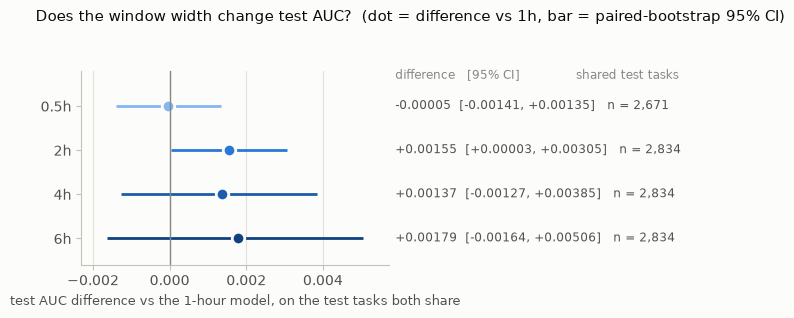

In [11]:
fig = ab.plot_paired_differences(paired)
fig.savefig(f"{FIG_DIR}/lookback_auc_vs_1h.png", dpi=150, bbox_inches="tight")
plt.show()

**Reading the performance table. Start from the last columns: on the same tasks, the window width does not change the model.**

The own-test-set columns seem to tell a clean story: AUC falls steadily from 0.7607 at 0.5h to 0.7416 at 6h, and accuracy and F1 fall with it. **That trend is not the window changing the model. It is the window changing which tasks are in the test set.** Three views show it:

1. **Paired against 1h on shared tasks.** The 0.5h and 1h models score the same 2,671 tasks at AUC 0.76070 and 0.76074, a difference of −0.00005 [−0.00141, +0.00135]. On the full canonical test set, 2h, 4h and 6h score +0.0015, +0.0014 and +0.0018 *higher* than 1h. No width moves AUC by as much as 0.002.
2. **All five on one task set.** On the 2,671 test tasks every width can score, the five models land at AUC 0.7607-0.7618, accuracy 0.8165-0.8173 and F1 0.5861-0.5873. With the population held fixed, they are indistinguishable.
3. **The decomposition.** Each width's change in own-test AUC splits into a model effect (the paired difference) and a coverage effect (the rest). The coverage effect is +0.0087 at 0.5h and −0.0082, −0.0101 and −0.0122 at 2h, 4h and 6h. The largest model effect is 0.0018.
   - A 30-minute window drops 163 canonical test tasks that are hard to rank. Without them, even the 1h model's AUC rises from 0.7520 to 0.7607.
   - A long window adds 96-177 test tasks from machines with sparse recent activity, which are harder still.

**Stated plainly: 1 hour is not the best-performing width.** On the canonical test tasks every wider window scores slightly higher than 1 hour. For 2h the paired 95% interval excludes zero, but only just: [+0.00003, +0.00305]. For 4h and 6h it includes zero. Three things keep that from being a reason to switch:
- The effect is about 0.0015 AUC, one-seventh of the split-to-split standard deviation Phase 5 measured for a single model (0.0104).
- It shrinks to +0.0010 on the 2,671 tasks every width shares.
- It is one borderline exclusion among four uncorrected comparisons.

Switching to 2 hours now would be exactly the post-hoc choice this ablation was set up to rule out. The canonical window stays at 1 hour, and the paper reports this result as it stands. Every model here, like Phase 5's, trains to the 500-epoch cap without early stopping firing, so the training budget is identical across widths. The validation losses are not comparable across widths, because each width validates on its own tasks.

### A4. Does the curve shape depend on the window?

Performance is only half the question. The paper's interpretive claims rest on the *shapes* of the $\varphi_i$ curves, so a window that left AUC alone but bent the telemetry curves would still be quietly encoding the finding. The two telemetry features compared here are the ones that entered the model in Phase 2 as replacements (`avg_cpu_kernel` for iowait, `avg_net_receive` for the GPU-type match). The table after the plot also ranks all ten features at every width.

**How the curves are aligned.** A longer window averages more telemetry rows, so the averages bunch closer together and each width's 5th-95th percentile window is narrower. Every curve is drawn over its own width's window, in raw units. It is shifted vertically by its mean over the **shaded shared window**, the x-range every width covers densely, so the curves share a common reference and only their shapes differ.

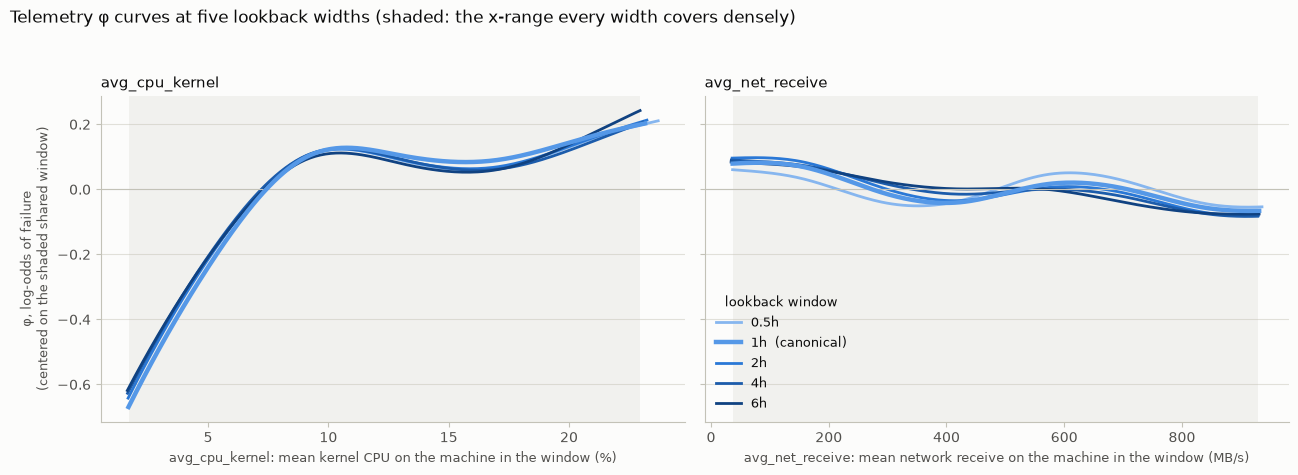

In [12]:
curves = ab.telemetry_curves(fitted, splits)
fig = ab.plot_telemetry_curves(curves, splits)
fig.savefig(f"{FIG_DIR}/lookback_telemetry_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [13]:
agreement = ab.curve_agreement(fitted, splits)
print("Each width's curve against the 1h curve, over the shared window (both centered there):\n")
print(agreement.to_string(formatters={
    "shared window low": "{:,.4g}".format, "shared window high": "{:,.4g}".format, "1h curve range": "{:.3f}".format,
    "this curve range": "{:.3f}".format, "max |dphi|": "{:.3f}".format, "mean |dphi|": "{:.3f}".format,
    "max |dphi| / 1h range": "{:.0%}".format, "shape correlation": "{:+.3f}".format}))

shares, ranks, rho = ab.importance_by_width(fitted, splits)
print("\nKAAM's built-in importance rank of all ten features at each width\n"
      "(1 = widest phi range over that width's own 5th-95th percentile window; the Phase 4-5 definition):\n")
print(ranks.rename(columns=lambda w: f"{w:g}h").to_string())
print("\nthe same as a share of total importance:\n")
print(shares.rename(columns=lambda w: f"{w:g}h").to_string(float_format="{:.3f}".format))
print("\nSpearman correlation of each width's ranking with the 1h ranking:")
print(rho.rename(lambda w: f"{w:g}h").to_string(float_format="{:.3f}".format))

Each width's curve against the 1h curve, over the shared window (both centered there):

                               shared window low shared window high 1h curve range this curve range max |dphi| mean |dphi| max |dphi| / 1h range shape correlation
feature         lookback hours                                                                                                                                    
avg_cpu_kernel  0.5                        1.696              22.95          0.868            0.812      0.055       0.018                    6%            +0.999
                2.0                        1.696              22.95          0.868            0.846      0.030       0.015                    3%            +0.999
                4.0                        1.696              22.95          0.868            0.824      0.048       0.020                    6%            +0.998
                6.0                        1.696              22.95          0.868            0.8

**Reading the curves. The headline telemetry curve keeps its shape at every width. The curve that does wobble is one the model barely uses.**

- **`avg_cpu_kernel` keeps its shape at every width.** All five curves rise steeply from about 2% to about 10% mean kernel CPU, a climb of roughly 0.75 log-odds. They level off with a slight dip between about 10% and 16%, then climb again toward 23%. Against the 1-hour curve, the shape correlation over the shared window is 0.996-0.999. The largest vertical departure is 0.03-0.06 log-odds, 3-7% of the curve's 0.87 log-odds range. Whatever the paper says about kernel CPU, it would say the same with a 30-minute or a 6-hour window.
- **`avg_net_receive` is small at every width, and only its small secondary bump moves.** The whole 1-hour curve spans 0.15 log-odds over the shared window, one-sixth of `avg_cpu_kernel`'s. Every width shows the same gentle decline: heavier network receive, slightly lower risk. What varies is a bump near 600 MB/s, about +0.05 at 0.5h and gone at 6h. That puts the shape correlation at 0.83-0.98, yet the largest absolute departure (0.046 log-odds) is smaller than `avg_cpu_kernel`'s. It is the least important feature at every width (rank 10 of 10), so no finding rests on the detail of its shape.
- **The importance ranking barely moves** (Spearman ρ against 1 hour: 0.94-0.99). `plan_cpu` is rank 1, `plan_mem` 2, `plan_gpu` 8 and `avg_net_receive` 10 at every width. The only movement is swaps between neighbours:
  - `avg_cpu_kernel` and `cap_gpu` trade ranks 3 and 4. At 1 hour they are tied to within 0.001 of importance share (0.127 vs 0.126).
  - `inst_num` and `avg_load_1` trade 5 and 6 at 2 hours.
  - From 4 hours up, `avg_gpu_util` climbs from 9 to 7 and `avg_cpu_usr` falls from 7 to 9. Longer windows move credit from user-space CPU (share 0.067 at 0.5h, 0.043 at 6h) to GPU utilization (0.023 to 0.050). That window dependence is real but modest, and it stays in the bottom half of the ranking.

### A5. Verdict: 1 hour was a defensible default, not a cherry-picked one

| Question | Answer |
|---|---|
| Does the window change **which tasks survive**? | **Yes, modestly.** Clean rows run from 17,751 (0.5h, −6.0%) to 20,067 (6h, +6.2%), in exactly nested sets. The marginal tasks differ in failure rate: 33% for the tasks a 30-minute window loses, 24% for the tasks a 4- or 6-hour window adds. |
| Does it change **model performance**? | **Not on the same tasks.** Paired against 1 hour: −0.00005, +0.0015, +0.0014 and +0.0018 AUC. On the 2,671 tasks every width scores, all five models land between AUC 0.7607 and 0.7618. |
| Is 1 hour the **best** width? | **No, and the paper should say so.** Every wider window is nominally better on the canonical test tasks. 2 hours excludes zero by 0.00003: one borderline result among four comparisons, about one-seventh the size of Phase 5's split-to-split noise. |
| Does it change the **curve shapes**? | **Not for `avg_cpu_kernel`** (shape correlation ≥ 0.996). **For `avg_net_receive`, only in a small secondary bump**, on a curve that spans 0.15 log-odds and ranks last at every width. |
| Does it change the **importance ranking**? | **Only among near-ties.** Ranks 1, 2, 8 and 10 are fixed. `avg_cpu_kernel` and `cap_gpu` trade 3 and 4 (tied at 1 hour); `avg_cpu_usr` and `avg_gpu_util` trade 7 and 9 from 4 hours up. |

**For the methodology section.** The 1-hour window needs one sentence of justification, not a defence, and the sentence should say what the window actually controls: **coverage, not model quality**.

The ablation also yields a warning worth putting in the paper. Compared on their own test sets, the widths would have shown a spurious 0.019-AUC advantage for short windows, and that advantage is entirely a change in which tasks can be scored. This is why every comparison here is paired on shared tasks.

The Phase 5 caveat carries over, now quantified. Headline metrics describe tasks whose machine had other jobs finish in the preceding window. Shortening that window makes the scored population easier to rank; it does not make the model better.

## Part B. Case-level explainability audit

KAAM predicts $\text{risk} = \sigma\big(b + \sum_i \varphi_i(x_i)\big)$, so any single prediction breaks down exactly into ten per-feature numbers. `explain()` returns them. Nobody had looked at that output for a real task. This part does, on the canonical Phase 5 model and its untouched 2,834-task test set.

### B1. Four cases, picked by a rule fixed in advance

| Case | Rule |
|---|---|
| True positive | the correctly caught failure with the **highest** predicted risk |
| True negative | the correctly cleared task with the **lowest** predicted risk |
| False negative | the missed failure with the **highest** predicted risk (the near miss) |
| False positive | the false alarm with the **highest** predicted risk (the most confidently wrong) |

The outcome groups are defined at the 0.5 threshold. The rule is applied mechanically to whatever the model predicts. Ties would go to the first task in test-set order and be reported. Tasks are shown by their row in the test set, not by Alibaba's job names.

In [14]:
cases = cs.select_cases(y_te, p_te, threshold=st.THRESHOLD)
print(f"canonical test set: {len(y_te):,} tasks at threshold {st.THRESHOLD}: "
      f"{m['tp']} TP, {m['tn']} TN, {m['fn']} FN, {m['fp']} FP\n")
print(cases.drop(columns="task").to_string(formatters={"predicted risk": "{:.4f}".format}))

canonical test set: 2,834 tasks at threshold 0.5: 366 TP, 1928 TN, 413 FN, 127 FP

               test row predicted risk true label flagged group size tasks tied at this risk                                                                      rule
case                                                                                                                                                                  
True positive      2342         0.7782          1    True        366                       1                  correctly caught failure with the highest predicted risk
True negative      2356         0.0242          0   False       1928                       1                     correctly cleared task with the lowest predicted risk
False negative     1116         0.4943          1   False        413                       1            missed failure with the highest predicted risk (the near miss)
False positive     1607         0.7817          0    True        127              

### B2. Reading one prediction as an audit trail

**Where every waterfall starts.** Each $\varphi_i$ curve has an arbitrary vertical level: adding a constant to one curve and subtracting it from the bias changes nothing the model predicts. The table below shows what that does to `explain()`'s raw output on this model.

In [15]:
scaled_tr = torch.tensor(st.scaled_matrix(X_tr, ranges))
with torch.no_grad():
    raw_phi = pd.DataFrame({name: kaam.edges[name](scaled_tr[:, i]).numpy() for i, name in enumerate(FEATURE_NAMES)})
phi_means = cs.phi_training_means(kaam, X_tr, ranges)
levels = pd.DataFrame({"min raw phi": raw_phi.min(), "training mean": phi_means, "max raw phi": raw_phi.max(),
                       "tasks with raw phi < 0": (raw_phi < 0).mean()})
print(f"explain()'s raw phi_i over the {len(X_tr):,} training tasks:\n")
print(levels.to_string(formatters={"min raw phi": "{:+.3f}".format, "training mean": "{:+.3f}".format,
                                   "max raw phi": "{:+.3f}".format, "tasks with raw phi < 0": "{:.0%}".format}))

baseline = float(kaam.bias.item() + phi_means.sum())
print(f"\nmodel bias {kaam.bias.item():+.4f} + sum of the ten training means {phi_means.sum():+.4f} "
      f"= {baseline:+.4f} log-odds -> risk {1 / (1 + np.exp(-baseline)):.4f}  <- where every waterfall starts")
print(f"for scale: mean predicted risk over training tasks {predict_proba(kaam, X_tr, ranges).mean():.4f}, "
      f"training failure rate {y_tr.mean():.4f}")

explain()'s raw phi_i over the 13,222 training tasks:

                min raw phi training mean max raw phi tasks with raw phi < 0
plan_cpu             -1.179        -0.559      +1.004                    80%
plan_mem             -0.840        +0.054      +0.369                    15%
plan_gpu             -0.485        -0.182      -0.002                   100%
inst_num             -0.607        -0.067      +0.003                    18%
avg_cpu_usr          -0.339        -0.100      +0.081                    70%
avg_gpu_util         -0.410        -0.162      -0.042                   100%
avg_cpu_kernel       -0.606        +0.106      +0.755                    28%
avg_load_1           -0.645        -0.264      -0.014                   100%
cap_gpu              -0.289        +0.310      +0.582                    31%
avg_net_receive      -0.224        -0.151      -0.076                   100%

model bias -0.1486 + sum of the ten training means -1.0146 = -1.1632 log-odds -> risk 0.2381  <- 

Four features (`plan_gpu`, `avg_gpu_util`, `avg_load_1`, `avg_net_receive`) have a raw $\varphi_i$ below zero for **every** training task. A raw waterfall would show them "lowering risk" in every case, whatever the task looked like. So each bar below is **$\varphi_i(x_i)$ minus $\varphi_i$'s training mean**: how much that feature moved *this* task's log-odds relative to the average training task. The waterfall starts at the average task's log-odds, $b + \sum_i \overline{\varphi_i}$ = −1.16 (risk 0.238), and ends at this task's log-odds, which is exactly the model's logit.

One detail on the starting point: 0.238 is the risk *at* the average log-odds, not the average risk. Averaging on the log-odds scale and then applying the sigmoid gives a smaller number than the 27.5% training failure rate, because the sigmoid is not linear.

**How to read a chart.** Bars run from the largest move to the smallest, each starting where the previous one ended. Red raises the failure risk, blue lowers it. Each row names the feature's raw value in the units an engineer sees, plus its percentile among the 13,222 training tasks (`p94` means higher than 94% of them). The dashed line is the 0.5 decision threshold, which is 0 on the log-odds scale. The table under each chart gives the raw `explain()` value next to the centered one.

In [16]:
tables = {}


def show_case(name):
    task = cases.loc[name, "task"]
    table = cs.explain_case(kaam, X_te, ranges, task, phi_means, X_reference=X_tr)
    risk = cases.loc[name, "predicted risk"]
    outcome = "Failed" if cases.loc[name, "true label"] == 1 else "Terminated"
    subtitle = (f"risk {risk:.3f} · {'flagged' if cases.loc[name, 'flagged'] else 'not flagged'} at ≥ {st.THRESHOLD:g} "
                f"· actual outcome: {outcome} · pNN = percentile among the {len(X_tr):,} training tasks")
    fig = cs.plot_waterfall(table, baseline, f"{name}: {cs.CASE_RULES[name]}", subtitle)
    fig.savefig(f"{FIG_DIR}/case_{name.lower().replace(' ', '_')}.png", dpi=150, bbox_inches="tight")
    plt.show()

    view = table.assign(**{"raw value": [cs.format_value(n, v) for n, v in table["raw value"].items()]})
    print(view.to_string(formatters={"training percentile": "{:.0f}".format, "scaled value": "{:.3f}".format,
                                     "phi = explain()": "{:+.4f}".format, "training mean of phi": "{:+.4f}".format,
                                     "vs average task": "{:+.4f}".format}))
    centered_total = baseline + table["vs average task"].sum()
    raw_total = kaam.bias.item() + table["phi = explain()"].sum()
    print(f"\ncentered route: average task {baseline:+.4f} + bars {table['vs average task'].sum():+.4f} "
          f"= {centered_total:+.4f} log-odds -> risk {1 / (1 + np.exp(-centered_total)):.4f}")
    print(f"raw route:      bias {kaam.bias.item():+.4f} + explain() {table['phi = explain()'].sum():+.4f} "
          f"= {raw_total:+.4f} log-odds (the same logit)")
    tables[name] = table

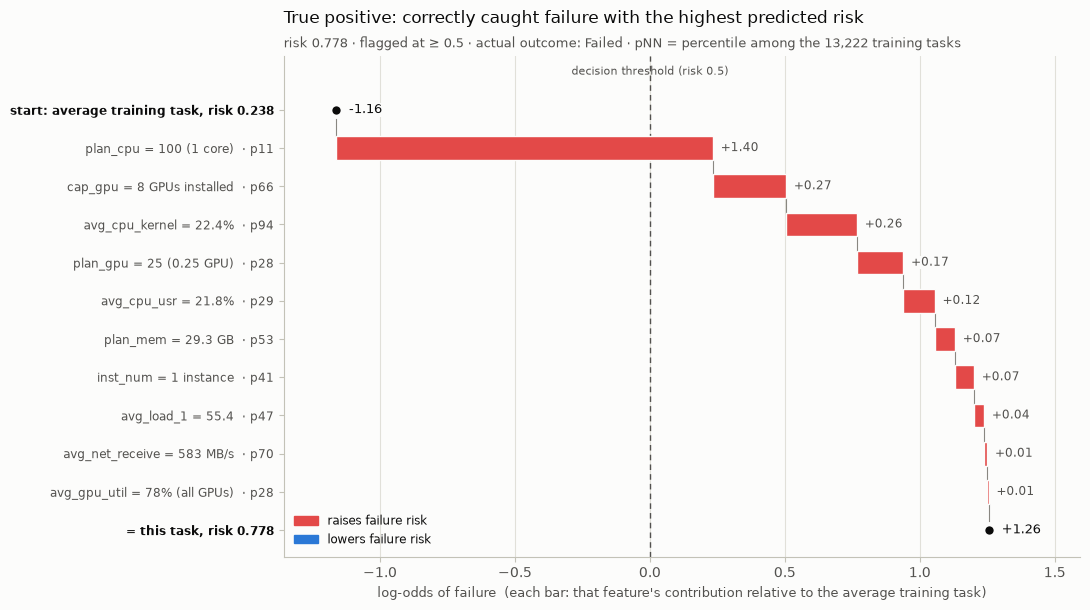

                        raw value training percentile scaled value phi = explain() training mean of phi vs average task
plan_cpu             100 (1 core)                  11        0.045         +0.8374              -0.5593         +1.3967
cap_gpu          8 GPUs installed                  66        1.000         +0.5815              +0.3104         +0.2711
avg_cpu_kernel              22.4%                  94        0.597         +0.3687              +0.1062         +0.2626
plan_gpu            25 (0.25 GPU)                  28        0.103         -0.0101              -0.1817         +0.1716
avg_cpu_usr                 21.8%                  29        0.304         +0.0164              -0.1002         +0.1166
plan_mem                  29.3 GB                  53        0.482         +0.1293              +0.0543         +0.0750
inst_num               1 instance                  41        0.000         +0.0031              -0.0672         +0.0703
avg_load_1                   55.4       

In [17]:
show_case("True positive")

**What the chart shows.** All ten bars point the same way, so the model had no reason to hesitate, but one feature does most of the work. The task asked for **a single CPU core** (`plan_cpu` = 100; 82% of training tasks ask for more). That alone adds +1.40 log-odds, 58% of the whole climb from the average task's −1.16 to +1.26. Next come the 8-GPU host (+0.27) and **the host's kernel CPU**: 22.4% on average in the hour before the task started, the 94th percentile, worth +0.26. A quarter-GPU request adds another +0.17.

**Would an SRE find it plausible?** The kernel-CPU reading is textbook: sustained kernel time means the host was busy with I/O, networking or context switches, which is the signature of a contended node. The 1-core reading is where an engineer should get suspicious, because "small CPU requests fail" is not a law of infrastructure. The analysis after the four cases shows why the model believes it. This exact request (1 core, 29.3 GB, 0.25 GPU, 1 instance, 8-GPU host) appears 1,492 times in training, 88.5% of those runs failed, and 99.7% of them come from one user. The chart reports faithfully what the model computes, and what the model has learned to spot is that user's recurring failing job.

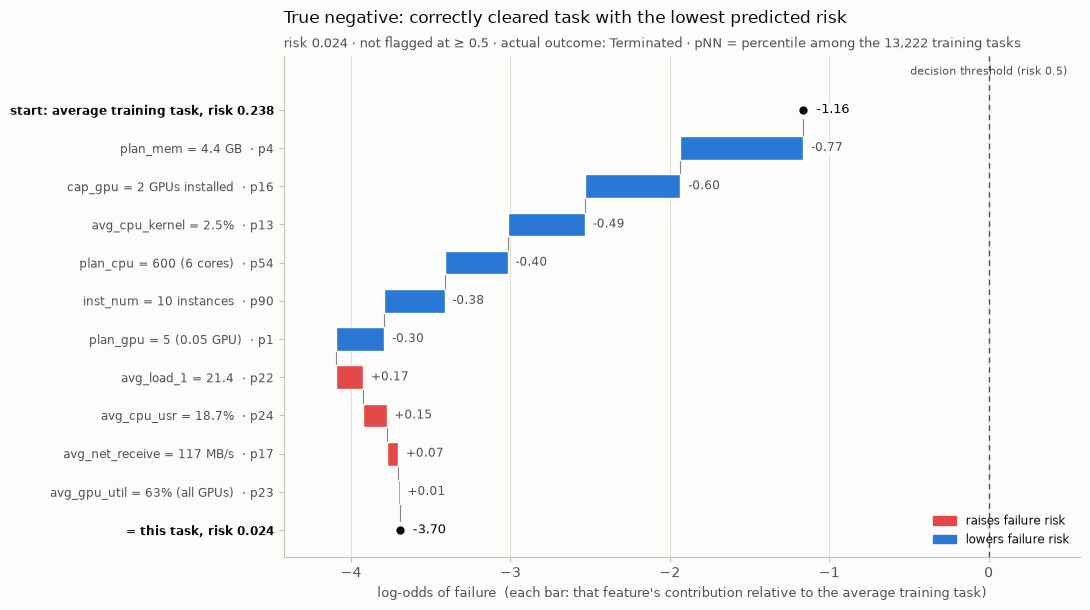

                        raw value training percentile scaled value phi = explain() training mean of phi vs average task
plan_mem                   4.4 GB                   4        0.042         -0.7160              +0.0543         -0.7703
cap_gpu          2 GPUs installed                  16        0.000         -0.2888              +0.3104         -0.5993
avg_cpu_kernel               2.5%                  13        0.043         -0.3790              +0.1062         -0.4852
plan_cpu            600 (6 cores)                  54        0.326         -0.9547              -0.5593         -0.3954
inst_num             10 instances                  90        0.184         -0.4457              -0.0672         -0.3785
plan_gpu             5 (0.05 GPU)                   1        0.000         -0.4847              -0.1817         -0.3029
avg_load_1                   21.4                  22        0.034         -0.0930              -0.2639         +0.1708
avg_cpu_usr                 18.7%       

In [18]:
show_case("True negative")

**What the chart shows.** No single feature clears this task. Six features each pull it down by 0.3 to 0.8 log-odds, and together they take it from the average task's −1.16 to −3.70 (risk 0.024):

| Feature | Value | Pull (log-odds) |
|---|---|---|
| memory request | 4.4 GB, 4th percentile | −0.77 |
| host size | 2-GPU host | −0.60 |
| host kernel CPU | 2.5%, 13th percentile | −0.49 |
| CPU request | 6 cores | −0.40 |
| instances | 10, a distributed task | −0.38 |
| GPU request | 0.05 GPU, 1st percentile | −0.30 |

The only bars pushing the other way say the host was *under*-used: a low load average (22nd percentile, +0.17) and low user-space CPU (24th percentile, +0.15).

**Would an SRE find it plausible?** Mostly, yes: a light, distributed task on a small, quiet node is what a job that finishes looks like. The surprise is the direction of those two host-utilization bars. An engineer expects a quieter host to make failure *less* likely, and KAAM's `avg_load_1` and `avg_cpu_usr` curves slope the other way. The same pattern shows up in the near miss below. One plausible reading is selection, not cause. The telemetry comes from other jobs' workers that *finished* on this host, so a busy recent history marks a host that has been completing work. The chart can raise that question; it cannot settle it.

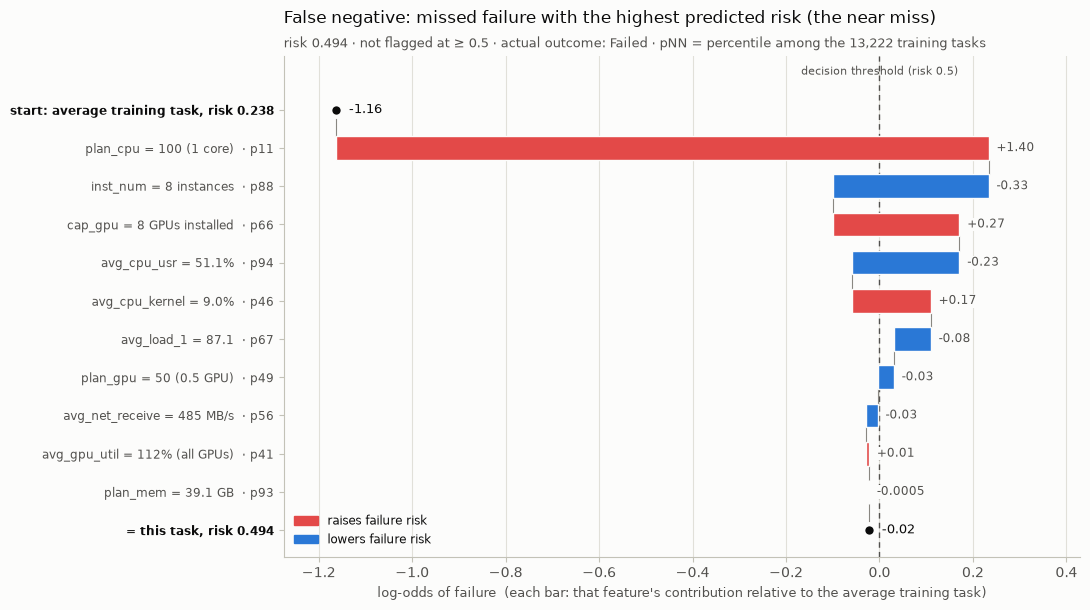

                        raw value training percentile scaled value phi = explain() training mean of phi vs average task
plan_cpu             100 (1 core)                  11        0.045         +0.8374              -0.5593         +1.3967
inst_num              8 instances                  88        0.143         -0.4008              -0.0672         -0.3336
cap_gpu          8 GPUs installed                  66        1.000         +0.5815              +0.3104         +0.2711
avg_cpu_usr                 51.1%                  94        0.733         -0.3299              -0.1002         -0.2297
avg_cpu_kernel               9.0%                  46        0.224         +0.2747              +0.1062         +0.1685
avg_load_1                   87.1                  67        0.151         -0.3430              -0.2639         -0.0791
plan_gpu             50 (0.5 GPU)                  49        0.231         -0.2164              -0.1817         -0.0346
avg_net_receive          485 MB/s       

In [19]:
show_case("False negative")

**What the chart shows.** This is the most informative miss in the test set: a real failure scored at 0.494, **0.006 under the threshold** (0.023 in log-odds). It carries the true positive's dominant signal, a 1-core request worth +1.40, along with an 8-GPU host (+0.27) and moderately high kernel CPU (+0.17). Two features pulled it back under the line: an **8-instance request** (88th percentile, −0.33) and a host whose **user-space CPU was at 51%** (94th percentile, −0.23).

**Would an SRE find it plausible?** The instance discount is backed by the data. This task is not the recurring template (no training task shares its exact request of 1 core, 39.1 GB, 0.5 GPU and 8 instances), and only 23.8% of the 63 training tasks that pair 1 core with 8 or more instances failed. The busy-host discount is the counterintuitive direction again. An engineer looking at a host at the 94th percentile of user CPU would lean toward *more* risk, and the model leaned away.

For operations, this is the case audit trails exist for. A reviewer can see exactly which two readings talked the model out of a flag, and decide whether to trust them. Where the threshold should sit is a separate question. Phase 5 held it at 0.5, and a recall-oriented rule remains an open item, not something to tune here.

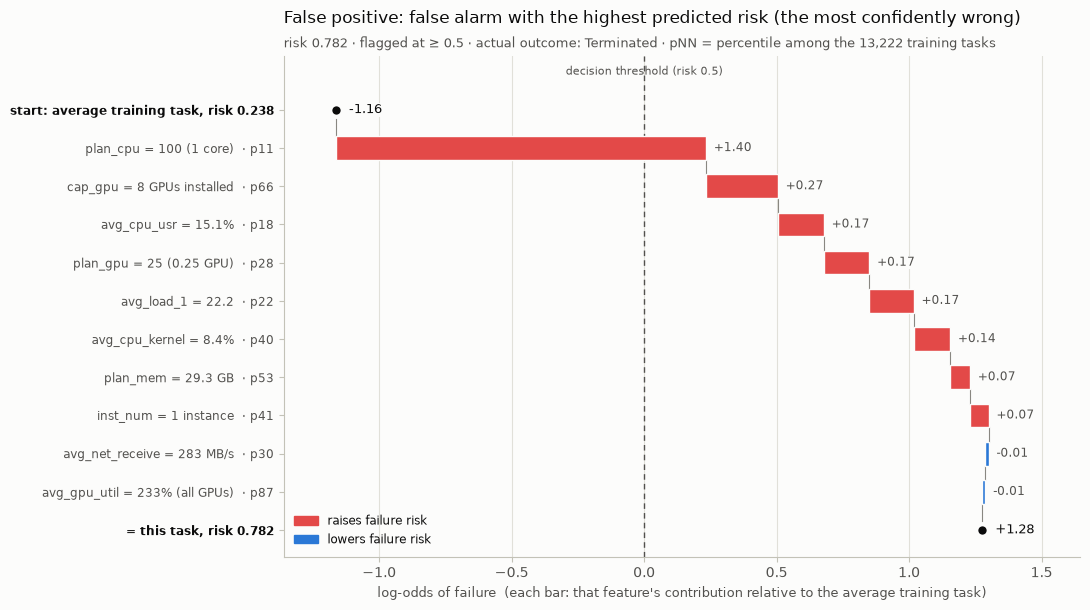

                        raw value training percentile scaled value phi = explain() training mean of phi vs average task
plan_cpu             100 (1 core)                  11        0.045         +0.8374              -0.5593         +1.3967
cap_gpu          8 GPUs installed                  66        1.000         +0.5815              +0.3104         +0.2711
avg_cpu_usr                 15.1%                  18        0.204         +0.0733              -0.1002         +0.1735
plan_gpu            25 (0.25 GPU)                  28        0.103         -0.0101              -0.1817         +0.1716
avg_load_1                   22.2                  22        0.036         -0.0963              -0.2639         +0.1676
avg_cpu_kernel               8.4%                  40        0.207         +0.2436              +0.1062         +0.1374
plan_mem                  29.3 GB                  53        0.482         +0.1293              +0.0543         +0.0750
inst_num               1 instance       

In [20]:
show_case("False positive")

**What the chart shows.** The most confidently wrong prediction in the test set made **the same request as the most confidently right one**: 1 core, 29.3 GB, a quarter GPU, 1 instance, an 8-GPU host. That request fixes the top of the waterfall: +1.40 for the core count, +0.27 for the host, +0.17 for the quarter GPU, and a little from memory and instance count. The telemetry differs from the true positive's but ends in the same place. Where the true positive's host ran hot on kernel CPU, this host was quiet on user CPU (18th percentile) and load (22nd percentile). KAAM reads both as mild risk (+0.17 each), and the two tasks end 0.02 log-odds apart (+1.28 against +1.26).

**Would an SRE find it plausible?** Yes, once the base rate is on the table, and the cells below put it there. 88.5% of the 1,492 training runs of this exact request failed, nearly all from one user. A risk score of 0.78 is, if anything, *low* for it: across the 330 test runs of this request the model's median score is 0.71, against an observed failure rate of 87.6%. This is not a reasoning error an engineer could correct by reading the chart. It is one of the roughly one-in-eight runs of a chronically failing job that happened to succeed, and nothing among the ten features tells those runs apart.

### Side by side: the four cases' raw inputs

In [21]:
side = pd.DataFrame({name: X_te.loc[cases.loc[name, "task"]] for name in cs.CASE_ORDER})
print(side.apply(lambda col: [cs.format_value(n, v) for n, v in col.items()]).to_string())

                    True positive     True negative    False negative    False positive
plan_cpu             100 (1 core)     600 (6 cores)      100 (1 core)      100 (1 core)
plan_mem                  29.3 GB            4.4 GB           39.1 GB           29.3 GB
plan_gpu            25 (0.25 GPU)      5 (0.05 GPU)      50 (0.5 GPU)     25 (0.25 GPU)
inst_num               1 instance      10 instances       8 instances        1 instance
avg_cpu_usr                 21.8%             18.7%             51.1%             15.1%
avg_gpu_util       78% (all GPUs)    63% (all GPUs)   112% (all GPUs)   233% (all GPUs)
avg_cpu_kernel              22.4%              2.5%              9.0%              8.4%
avg_load_1                   55.4              21.4              87.1              22.2
cap_gpu          8 GPUs installed  2 GPUs installed  8 GPUs installed  8 GPUs installed
avg_net_receive          583 MB/s          117 MB/s          485 MB/s          283 MB/s


The true positive and the false positive asked for exactly the same thing and ran on the same kind of host. The next cell follows that up in the training data. It checks how common each case's request profile is, how often it failed, and who submits it. `pai_job_table` maps each job to its submitting user, and the trace already stores those as hashes. Only counts and shares are printed, never an identifier.

In [22]:
REQUEST = ["plan_cpu", "plan_mem", "plan_gpu", "inst_num", "cap_gpu"]  # what the task asked for, and where it ran
job_user = (pd.read_csv(f"{RAW_DIR}/pai_job_table.csv", usecols=["job_name", "user"])
            .drop_duplicates("job_name").set_index("job_name")["user"])
user = pd.Series(job_user.reindex(X_large.index.get_level_values("job_name")).to_numpy(), index=X_large.index)
print(f"users matched for {user.notna().mean():.1%} of the {len(user):,} tasks; {user.nunique():,} distinct users\n")

rows = {}
for name in cs.CASE_ORDER:
    profile = X_te.loc[cases.loc[name, "task"], REQUEST]
    same = (X_tr[REQUEST] == profile).all(axis=1)
    who = user.loc[X_tr.index[same]]
    rows[name] = {"training tasks with this exact request": int(same.sum()),
                  "their failure rate": y_tr[same].mean() if same.any() else np.nan,
                  "distinct users": who.nunique(),
                  "largest user's share": who.value_counts(normalize=True).iloc[0] if same.any() else np.nan}
share = lambda v: "-" if pd.isna(v) else f"{v:.1%}"
print(pd.DataFrame(rows).T.to_string(formatters={"training tasks with this exact request": "{:,.0f}".format,
                                                 "their failure rate": share, "distinct users": "{:,.0f}".format,
                                                 "largest user's share": share}))
near = (X_tr["plan_cpu"] == 100) & (X_tr["inst_num"] >= 8)
print(f"the near miss's closest group, 1-core tasks with 8 or more instances: {int(near.sum())} training tasks, "
      f"failure rate {y_tr[near].mean():.1%}")

template = X_te.loc[cases.loc["True positive", "task"], REQUEST]
top = user.loc[X_tr.index[(X_tr[REQUEST] == template).all(axis=1)]].value_counts().index[0]  # its main submitter
is_top = user == top
print(f"\nThe template's main submitter is the largest user in the whole dataset: {user.value_counts().index[0] == top}")
print(f"  {int(is_top.sum()):,} of {len(user):,} tasks ({is_top.mean():.1%}), failure rate {y_large[is_top].mean():.1%}, "
      f"{y_large[is_top].sum() / y_large.sum():.1%} of all failures")

one_core, top_tr = X_tr["plan_cpu"] == 100, is_top.loc[X_tr.index]
print("\nTraining failure rates:")
for label, mask in {"1-core tasks, this user": one_core & top_tr, "1-core tasks, all other users": one_core & ~top_tr,
                    "every other task (not exactly 1 core)": ~one_core}.items():
    n_users = user.loc[X_tr.index[mask]].nunique()
    print(f"  {label:<40s} {int(mask.sum()):>6,} tasks from {n_users:>4,} user{'' if n_users == 1 else 's'}, "
          f"failure rate {y_tr[mask].mean():.1%}")

in_template = (X_te[REQUEST] == template).all(axis=1)
other_one_core = (X_te["plan_cpu"] == 100) & ~in_template
flagged = p_te >= st.THRESHOLD
print(f"\nTest set at threshold {st.THRESHOLD}:")
print(f"  the template: {int(in_template.sum())} tasks, failure rate {y_te[in_template].mean():.1%}, median predicted risk "
      f"{p_te[in_template].median():.3f}; {int((flagged & in_template & (y_te == 1)).sum())} of the {m['tp']} true "
      f"positives and {int((flagged & in_template & (y_te == 0)).sum())} of the {m['fp']} false positives")
print(f"  other 1-core tasks: {int(other_one_core.sum())} tasks, failure rate {y_te[other_one_core].mean():.1%}, mean "
      f"predicted risk {p_te[other_one_core].mean():.3f}; {int((flagged & other_one_core & (y_te == 0)).sum())} more "
      f"false positives")

rows = {}
for label, mask in {"all test tasks": pd.Series(True, index=y_te.index), "without the template": ~in_template,
                    "without the template's user": ~is_top.loc[X_te.index]}.items():
    mm = classification_metrics(y_te[mask].to_numpy(), p_te[mask].to_numpy(), st.THRESHOLD)
    rows[label] = {"tasks": int(mask.sum()), "failure rate": y_te[mask].mean(), "AUC": mm["auc"],
                   "accuracy": mm["accuracy"], "recall": mm["recall"], "F1": mm["f1"]}
print("\nThe canonical model's test metrics with and without that user (a description of the same predictions, "
      "not a new evaluation):\n")
print(pd.DataFrame(rows).T.to_string(formatters={"tasks": "{:,.0f}".format, "failure rate": "{:.1%}".format,
                                                 "AUC": "{:.4f}".format, "accuracy": "{:.4f}".format,
                                                 "recall": "{:.4f}".format, "F1": "{:.4f}".format}))

users matched for 100.0% of the 18,890 tasks; 738 distinct users

               training tasks with this exact request their failure rate distinct users largest user's share
True positive                                   1,492              88.5%              3                99.7%
True negative                                       0                NaN              0                  NaN
False negative                                      0                NaN              0                  NaN
False positive                                  1,492              88.5%              3                99.7%
the near miss's closest group, 1-core tasks with 8 or more instances: 63 training tasks, failure rate 23.8%

The template's main submitter is the largest user in the whole dataset: True
  5,864 of 18,890 tasks (31.0%), failure rate 48.0%, 54.2% of all failures

Training failure rates:
  1-core tasks, this user                   1,496 tasks from    1 user, failure rate 88.0%
  1-core tas

**What the four cases show together: the audit trail found a data issue that the aggregate metrics hid.** Three of the four cases have a 1-core request as their largest bar, and the two most confident predictions share one request exactly. Following that thread back into the raw trace:

- **One user dominates the signal.** The template (1 core, 29.3 GB, 0.25 GPU, 1 instance, 8-GPU host) appears 1,492 times in training, 99.7% of them from a single user, and 88.5% of them failed. That user is also the largest in the dataset: 31.0% of all 18,890 tasks and **54.2% of all failures**.
- **The 1-core effect *is* that user.** Their 1-core training tasks fail at 88.0%. The 1-core tasks of the other 78 users fail at 16.6%, *below* the 19.9% rate of every other task. KAAM's largest curve, `plan_cpu`, carries about 29% of its importance, and it is mostly recognising one user's recurring job.
- **Additivity forces a compromise.** `plan_cpu` = 100 gets one contribution, identical for everyone. The template is under-predicted (median risk 0.71 against 87.6% observed). Other users' 1-core tasks are over-predicted (mean 0.54 against 27.7% observed), which puts 36 of the 127 false positives on them.
- **The headline numbers lean on this user.** The template supplies 289 of the model's 366 true positives. Without it, the canonical model's test AUC is 0.6257; without that user entirely, 0.6605. Overall it is 0.7520.

**What this does and does not mean.**
- It is not leakage in the usual sense. A task's request fields are known when it is submitted, and a production scheduler would have seen this user's earlier runs too.
- It does mean Table 1 measures a mixture of "recognise a known failing job" and "predict failure in general", and the second is much harder.
- It may also explain Phase 5's open `plan_gpu` puzzle, where the MLP ranked `plan_gpu` 3rd and KAAM 8th. A network that can combine `plan_cpu` = 100 with `plan_gpu` = 25 can isolate the template and treat other users' 1-core tasks differently, which an additive model cannot. That is a hypothesis, not a result.

None of this changes Phase 6's pipeline, which stays frozen as specified. It is recorded here, with numbers, as the most important open item this audit produced.

### B3. Consistency check: is `explain()` the model's own arithmetic?

`forward()` and `explain()` are separate code paths in `model.py`. `forward()` evaluates all ten edges on a batch, stacks them, sums them, adds the bias and applies the sigmoid. `explain()` evaluates each edge on a single value and returns ten Python floats. If they ever disagreed by more than floating-point noise, every chart above would be describing something other than what the model computes.

`forward()` returns only the probability, and `model.py` stays unmodified. So the logit is read where `forward()` hands it to `torch.sigmoid` during a real forward pass (`cs.forward_logits`), rather than recovered by inverting a float32 probability, which loses precision near 0 and 1. The check runs on the **raw** `explain()` values plus the model's bias.

In [23]:
checks = cs.consistency_check(kaam, X_te, ranges, list(cases["task"]), labels=cases.index)
print(checks.to_string(formatters={
    "sum of explain()": "{:+.8f}".format, "bias": "{:+.8f}".format, "explain() + bias": "{:+.8f}".format,
    "forward() logit": "{:+.8f}".format, "|logit difference|": "{:.2e}".format,
    "sigmoid(explain() + bias)": "{:.8f}".format, "forward() risk": "{:.8f}".format, "|risk difference|": "{:.2e}".format}))

max_gap = checks["|logit difference|"].max()
print(f"\nMAX |explain() + bias - forward() logit| over the four cases: {max_gap:.2e} log-odds")
print(f"  float32 spacing at the largest |logit| here ({checks['forward() logit'].abs().max():.2f}): "
      f"{np.spacing(np.float32(checks['forward() logit'].abs().max())):.2e}")
assert max_gap < 1e-4, "explain() and forward() disagree: a real bug, not a rounding note"

shap_cases = kaam_shap_values(kaam, X_tr, X_te.loc[list(cases["task"])], ranges)
shap_gap = max((tables[n]["vs average task"] - shap_cases.loc[cases.loc[n, "task"], tables[n].index]).abs().max()
               for n in cs.CASE_ORDER)
print(f"\nand the centered bars against Phase 4's closed-form kaam_shap_values (training tasks as background): "
      f"max |difference| {shap_gap:.1e}")

print("\nThe four cases in one table:\n")
print(cs.case_summary(cases, checks).to_string(formatters={
    "predicted risk": "{:.4f}".format, "explain() + bias": "{:+.6f}".format, "forward() logit": "{:+.6f}".format,
    "|logit difference|": "{:.1e}".format, "|risk difference|": "{:.1e}".format}))

               sum of explain()        bias explain() + bias forward() logit |logit difference| sigmoid(explain() + bias) forward() risk |risk difference|
True positive       +1.40366170 -0.14859566      +1.25506603     +1.25506604           2.79e-09                0.77817558     0.77817553          5.11e-08
True negative       -3.54642305 -0.14859566      -3.69501871     -3.69501877           5.59e-08                0.02424458     0.02424458          3.33e-10
False negative      +0.12576925 -0.14859566      -0.02282641     -0.02282640           1.12e-08                0.49429364     0.49429363          1.40e-08
False positive      +1.42447416 -0.14859566      +1.27587850     +1.27587855           5.12e-08                0.78174739     0.78174740          1.19e-08

MAX |explain() + bias - forward() logit| over the four cases: 5.59e-08 log-odds
  float32 spacing at the largest |logit| here (3.70): 2.38e-07

and the centered bars against Phase 4's closed-form kaam_shap_values (training t

**The decomposition is exact.** For all four cases, the ten raw `explain()` values plus the bias reproduce the logit `forward()` computed. The largest disagreement is 5.6 × 10⁻⁸ log-odds, a quarter of the float32 spacing at these logits (2.4 × 10⁻⁷), and the risk scores agree to within 5 × 10⁻⁸. `explain()` and `forward()` compute the same additive sum by two different code paths, and they agree to rounding.

The centered bars in the waterfalls match Phase 4's closed-form `kaam_shap_values` to 7 × 10⁻⁸. So every chart above is exact: it is the model's own arithmetic, re-expressed relative to the average training task, and it *is* that task's SHAP decomposition, obtained with no sampling and no approximation.

## Summary

| Question | Answer |
|---|---|
| **Phase 5 canonical model** | Phase 5 saved no checkpoint or split. Rebuilt by its canonical rule (split 42, seed 0), the model reproduces the exported test AUC 0.7519987881 and every other Table 1 metric exactly. It is now saved in `models/kaam_canonical.pt`. |
| **Lookback coverage** | Nested task sets: 17,751 / **18,890** / 19,524 / 19,911 / 20,067 clean rows at 0.5 / **1** / 2 / 4 / 6 h. The window changes the population at the edges: tasks needing 30-60 minutes of history fail at 33%. |
| **Lookback performance** | Paired against 1h on shared tasks: −0.00005, +0.0015, +0.0014, +0.0018 AUC. Only 2h's CI excludes zero, by 0.00003. The own-test-set trend (0.7607 down to 0.7416) is a coverage effect; on one common task set all five models score 0.7607-0.7618. |
| **Curve shapes** | `avg_cpu_kernel` keeps its shape (correlation ≥ 0.996). `avg_net_receive` varies only in a small bump, on a curve spanning 0.15 log-odds and ranked last everywhere. Ranks 1, 2, 8 and 10 are identical at all five widths. |
| **Verdict on 1 hour** | Defensible, not load-bearing. It is not the best-performing width: wider windows are marginally, mostly not significantly, better. Reported as it stands, and not switched, to avoid post-hoc selection. |
| **The four cases** | Picked by the fixed rule: TP risk 0.778, TN 0.024, FN 0.494 (0.006 under the threshold), FP 0.782. No ties. |
| **explain() vs forward()** | They agree to 5.6 × 10⁻⁸ log-odds, which is float32 rounding. The centered bars equal the closed-form SHAP values to 7 × 10⁻⁸. |
| **What the audit found** | The top TP and the top FP are the same request template: one user's recurring TensorFlow job, which fails 88.5% of the time. That user is 31% of tasks and 54% of failures. Without the template, test AUC is 0.6257. `plan_cpu`'s dominance is mostly this user. |

Figures are in `figures/phase6/`: `lookback_auc_vs_1h.png`, `lookback_telemetry_curves.png`, and `case_true_positive.png`, `case_true_negative.png`, `case_false_negative.png`, `case_false_positive.png`.

### Open items this phase adds

- **A user-grouped evaluation.** Re-run Table 1 on a split grouped by user, with and without the dominant user, to measure how well each model generalizes to submitters it has never seen. This is the most important next step, because it bears on every headline number since Phase 5.
- **The `plan_gpu` hypothesis.** Test whether the MLP's extra `plan_gpu` credit in Phase 5 is the template interaction identified here.
- **The window.** Nothing here justifies changing it. For a full-trace run it is worth knowing that windows of 2 hours or more keep up to 6% more tasks at no measurable cost.
- **Carried over from Phase 5.** The 500-epoch cap still binds at every width, and a recall-oriented threshold rule is still open.